# TRIDENT-201 Clinical and Protein Biomarker Analysis

## Overall objective

Evaluate the quality and biological characteristics of the TRIDENT-201 clinical
and baseline protein biomarker datasets before conducting inferential statistical
analyses.

## Specific objectives

1. Load the original clinical and protein biomarker datasets without modifying the raw files.
2. Assess dataset dimensions, column names, data types, missingness, duplicates, and impossible values.
3. Investigate known clinical anomalies, including duplicate patient records, implausible age,
   invalid ECOG status, negative progression-free survival, and missing best overall response.
4. Assess the protein biomarker dataset for duplicate samples, missing values, nonpositive
   measurements, inconsistent treatment-arm labels, and possible assay-related anomalies.
5. Create cleaned clinical and protein analysis datasets while preserving an audit trail.
6. Merge baseline protein biomarker measurements with relevant clinical information.
7. Characterize the distribution of baseline IL-6.
8. Compare baseline IL-6 distributions between treatment arms.
9. examine the biological relationship between IL-6 and CRP.
10. Prepare the dataset for Pearson and Spearman biomarker correlation analyses.

## Scientific principle

Quality control is performed before statistical testing because technical artifacts,
data-entry errors, duplicates, missingness, and biologically implausible values can
distort downstream conclusions.

## 1. Environment setup

### Objective

Import the Python libraries required for data manipulation and visualization, and
define reproducible paths to the raw and processed data directories.

The original files in `data/raw` will remain unchanged.

In [1]:
# Import libraries for data manipulation, visualization, and file paths

from pathlib import Path

# Identify the project root whether the notebook is launched
# from the repository root or from the notebooks folder
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

# Define project data and results directories
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

# Confirm that required input folders exist
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(f"Raw data folder not found: {RAW_DATA_DIR}")

# Create output folders if needed
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Project root: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis
Raw data directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/raw
Processed data directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/processed
Results directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results
Figures directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/figures


In [2]:
# Core data analysis and visualization packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Display all columns and make numerical output easier to inspect

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [4]:
from pathlib import Path

print("Current working directory:", Path.cwd())
print("Parent directory:", Path.cwd().parent)

Current working directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/notebooks
Parent directory: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis


In [5]:
# Confirm that the expected raw files are present

sorted(file.name for file in RAW_DATA_DIR.iterdir())

['adverse_events.csv',
 'biomarkers.csv',
 'clinical.csv',
 'labs.csv',
 'mutations.csv',
 'rna_expression.csv']

## 2. Data intake

### Objective

Load the clinical and protein biomarker datasets into pandas DataFrames and verify
that the files were read successfully.

The raw files are treated as immutable source data. All corrections will be made
in copied DataFrames.

In [6]:
# Load the clinical and protein biomarker datasets

clinical_raw = pd.read_csv(RAW_DATA_DIR / "clinical.csv")
protein_raw = pd.read_csv(RAW_DATA_DIR / "biomarkers.csv")

In [7]:
# Create working copies so the original loaded DataFrames remain unchanged

clinical = clinical_raw.copy()
protein = protein_raw.copy()

In [8]:
# Inspect the first five clinical records

clinical.head()

,patient_id,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site,enrollment_date
0,TRI-001,TRIDENT + SOC,71,Female,IV,1,Former,Adenocarcinoma,PD,323,1,323,1,SITE-10,2024-09-15
1,TRI-002,SOC,69,Female,III,2,Current,Adenocarcinoma,PR,20,1,126,0,SITE-12,2024-01-30
2,TRI-003,TRIDENT + SOC,80,Male,IV,1,Current,Other,SD,159,0,363,1,SITE-06,2024-10-28
3,TRI-004,SOC,51,Male,III,1,Former,Adenocarcinoma,PD,328,0,548,0,SITE-09,2024-01-21
4,TRI-005,TRIDENT + SOC,63,Female,IV,1,Never,Adenocarcinoma,PD,425,1,474,0,SITE-01,2024-02-21


In [9]:
# Inspect the first five protein biomarker records

protein.head()

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
0,TRI-001,Baseline,11.980,8.180,9.220,4.210,258.100,59.200,0.940
1,TRI-002,Baseline,6.780,8.020,8.410,3.990,9.000,32.400,2.310
2,TRI-003,Baseline,10.610,6.870,6.950,4.900,311.600,29.500,3.880
3,TRI-004,Baseline,13.820,8.860,7.130,3.570,202.700,3.400,2.860
4,TRI-005,Baseline,8.600,11.720,3.250,2.590,178.600,11.900,7.210


In [10]:
# Compare the dimensions of the two datasets

print("Clinical dataset shape:", clinical.shape)
print("Protein dataset shape:", protein.shape)

Clinical dataset shape: (251, 15)
Protein dataset shape: (248, 9)


## 3. Clinical dataset quality control

### Objective

Evaluate the clinical dataset for:

- unexpected dimensions,
- incorrect data types,
- missing values,
- duplicate patient records,
- inconsistent categorical values,
- biologically impossible or clinically implausible values,
- and survival-time inconsistencies.

Potential problems will be investigated before records are changed or excluded.

In [11]:
# Display the clinical column names

clinical.columns.tolist()

['patient_id',
 'treatment_arm',
 'age',
 'sex',
 'disease_stage',
 'ecog_status',
 'smoking_status',
 'histology',
 'best_overall_response',
 'pfs_days',
 'pfs_event',
 'os_days',
 'os_event',
 'study_site',
 'enrollment_date']

In [12]:
# Review clinical data types and nonmissing counts

clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   patient_id             251 non-null    object
 1   treatment_arm          251 non-null    object
 2   age                    251 non-null    int64 
 3   sex                    251 non-null    object
 4   disease_stage          251 non-null    object
 5   ecog_status            251 non-null    int64 
 6   smoking_status         251 non-null    object
 7   histology              251 non-null    object
 8   best_overall_response  250 non-null    object
 9   pfs_days               251 non-null    int64 
 10  pfs_event              251 non-null    int64 
 11  os_days                251 non-null    int64 
 12  os_event               251 non-null    int64 
 13  study_site             251 non-null    object
 14  enrollment_date        251 non-null    object
dtypes: int64(6), object(9)


In [13]:
# Summarize numerical clinical variables

clinical.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,251,250,TRI-075,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment_arm,251,3,TRIDENT + SOC,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,251.000,NaN,NaN,NaN,63.896,11.450,36.000,57.000,64.000,71.000,152.000
sex,251,3,Male,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease_stage,251,2,IV,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ecog_status,251.000,NaN,NaN,NaN,0.996,0.767,0.000,1.000,1.000,1.000,7.000
smoking_status,251,3,Former,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
histology,251,3,Adenocarcinoma,170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
best_overall_response,250,4,PD,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pfs_days,251.000,NaN,NaN,NaN,250.398,111.858,-14.000,168.000,257.000,326.000,549.000


In [14]:
# Count unique patients and compare them with the number of rows

print("Number of rows:", len(clinical))
print("Number of unique patient IDs:", clinical["patient_id"].nunique())
print("Difference:", len(clinical) - clinical["patient_id"].nunique())

Number of rows: 251
Number of unique patient IDs: 250
Difference: 1


In [15]:
# Count and rank missing values in the clinical dataset

clinical_missing = (
    clinical.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

clinical_missing["missing_percent"] = (
    clinical_missing["missing_count"] / len(clinical) * 100
)

clinical_missing

,missing_count,missing_percent
best_overall_response,1,0.398
patient_id,0,0.000
treatment_arm,0,0.000
age,0,0.000
sex,0,0.000
disease_stage,0,0.000
ecog_status,0,0.000
smoking_status,0,0.000
histology,0,0.000
pfs_days,0,0.000


In [16]:
# Display clinical records containing at least one missing value

clinical.loc[clinical.isna().any(axis=1)]

,patient_id,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site,enrollment_date
101,TRI-102,SOC,73,Male,IV,0,Current,Adenocarcinoma,NaN,490,0,498,1,SITE-07,2024-09-16


In [17]:
# Identify all records belonging to duplicated patient IDs

clinical_duplicates = clinical.loc[
    clinical["patient_id"].duplicated(keep=False)
].sort_values("patient_id")

clinical_duplicates

,patient_id,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site,enrollment_date
74,TRI-075,TRIDENT + SOC,47,Male,IV,1,Current,Adenocarcinoma,PR,279,1,492,1,SITE-07,2024-02-06
250,TRI-075,TRIDENT + SOC,47,Male,IV,1,Current,Adenocarcinoma,PR,279,1,492,1,SITE-07,2024-02-06


In [18]:
# Check whether duplicated patient records are fully identical

clinical_duplicates.duplicated(keep=False)

74     True
250    True
dtype: bool

In [19]:
# Remove exact duplicate rows while preserving one valid copy

clinical_clean = clinical.drop_duplicates().copy()

print("Rows before removing exact duplicates:", len(clinical))
print("Rows after removing exact duplicates:", len(clinical_clean))
print("Unique patients after cleaning:", clinical_clean["patient_id"].nunique())

Rows before removing exact duplicates: 251
Rows after removing exact duplicates: 250
Unique patients after cleaning: 250


In [20]:
# Confirm that every patient ID now appears only once

clinical_clean["patient_id"].value_counts().head()

patient_id
TRI-001    1
TRI-172    1
TRI-159    1
TRI-160    1
TRI-161    1
Name: count, dtype: int64

In [21]:
# Assert that the cleaned clinical dataset has one row per patient

assert clinical_clean["patient_id"].is_unique

In [22]:
# Display unique values for important clinical categorical variables

categorical_columns = [
    "treatment_arm",
    "sex",
    "disease_stage",
    "ecog_status",
    "smoking_status",
    "histology",
    "best_overall_response",
    "study_site",
]

for column in categorical_columns:
    if column in clinical_clean.columns:
        print(f"\n{column}")
        print(clinical_clean[column].value_counts(dropna=False))


treatment_arm
treatment_arm
SOC              125
TRIDENT + SOC    124
Trident + SOC      1
Name: count, dtype: int64

sex
sex
Male      140
Female    109
F           1
Name: count, dtype: int64

disease_stage
disease_stage
IV     177
III     73
Name: count, dtype: int64

ecog_status
ecog_status
1    138
0     59
2     52
7      1
Name: count, dtype: int64

smoking_status
smoking_status
Former     141
Never       64
Current     45
Name: count, dtype: int64

histology
histology
Adenocarcinoma    169
Squamous           61
Other              20
Name: count, dtype: int64

best_overall_response
best_overall_response
PD     91
SD     90
PR     63
CR      5
NaN     1
Name: count, dtype: int64

study_site
study_site
SITE-08    26
SITE-12    25
SITE-01    22
SITE-04    22
SITE-06    21
SITE-05    21
SITE-11    21
SITE-07    21
SITE-10    20
SITE-09    19
SITE-03    16
SITE-02    16
Name: count, dtype: int64


In [23]:
# Identify patients with clinically implausible ages

clinical_clean.loc[
    (clinical_clean["age"] < 18) | (clinical_clean["age"] > 100),
    ["patient_id", "age", "treatment_arm"]
]

,patient_id,age,treatment_arm
16,TRI-017,152,TRIDENT + SOC


In [24]:
# Create an age quality-control flag without changing the original value

clinical_clean["age_qc_flag"] = np.where(
    clinical_clean["age"].between(18, 100),
    "PASS",
    "REVIEW"
)

clinical_clean["age_qc_flag"].value_counts()

age_qc_flag
PASS      249
REVIEW      1
Name: count, dtype: int64

In [25]:
# Identify ECOG values outside the standard 0-to-5 scale

clinical_clean.loc[
    ~clinical_clean["ecog_status"].between(0, 5),
    ["patient_id", "ecog_status", "treatment_arm"]
]

,patient_id,ecog_status,treatment_arm
88,TRI-089,7,TRIDENT + SOC


In [26]:
# Create an ECOG quality-control flag

clinical_clean["ecog_qc_flag"] = np.where(
    clinical_clean["ecog_status"].between(0, 5),
    "PASS",
    "REVIEW"
)

In [27]:
# Identify negative or zero progression-free survival times

clinical_clean.loc[
    clinical_clean["pfs_days"] < 0,
    ["patient_id", "pfs_days", "pfs_event", "os_days", "os_event"]
]

,patient_id,pfs_days,pfs_event,os_days,os_event
137,TRI-138,-14,1,347,0


In [28]:
# Identify negative overall-survival times

clinical_clean.loc[
    clinical_clean["os_days"] < 0,
    ["patient_id", "os_days", "os_event"]
]

,patient_id,os_days,os_event


In [29]:
# Check whether PFS exceeds OS for any patient

clinical_clean.loc[
    clinical_clean["pfs_days"] > clinical_clean["os_days"],
    ["patient_id", "pfs_days", "os_days", "pfs_event", "os_event"]
]

,patient_id,pfs_days,os_days,pfs_event,os_event


In [30]:
# Check that event indicators contain only 0 and 1

print("PFS event values:", sorted(clinical_clean["pfs_event"].dropna().unique()))
print("OS event values:", sorted(clinical_clean["os_event"].dropna().unique()))

PFS event values: [0, 1]
OS event values: [0, 1]


In [31]:
# Create a PFS quality-control flag

clinical_clean["pfs_qc_flag"] = np.where(
    clinical_clean["pfs_days"] >= 0,
    "PASS",
    "REVIEW"
)

In [32]:
# Collect all clinical records requiring source-data review

clinical_qc_review = clinical_clean.loc[
    (clinical_clean["age_qc_flag"] == "REVIEW")
    | (clinical_clean["ecog_qc_flag"] == "REVIEW")
    | (clinical_clean["pfs_qc_flag"] == "REVIEW")
    | (clinical_clean["best_overall_response"].isna())
].copy()

clinical_qc_review[
    [
        "patient_id",
        "age",
        "ecog_status",
        "best_overall_response",
        "pfs_days",
        "age_qc_flag",
        "ecog_qc_flag",
        "pfs_qc_flag",
    ]
]

,patient_id,age,ecog_status,best_overall_response,pfs_days,age_qc_flag,ecog_qc_flag,pfs_qc_flag
16,TRI-017,152,1,PD,394,REVIEW,PASS,PASS
88,TRI-089,73,7,PR,406,PASS,REVIEW,PASS
101,TRI-102,73,0,NaN,490,PASS,PASS,PASS
137,TRI-138,77,1,SD,-14,PASS,PASS,REVIEW


### Clinical QC interpretation

The clinical dataset contained one exact duplicate patient record, which was removed
while preserving one valid copy. Four additional issues require source-data review:

- TRI-017: implausible age of 152 years.
- TRI-089: ECOG performance status of 7.
- TRI-102: missing best overall response.
- TRI-138: negative progression-free survival time of -14 days.

These values were flagged rather than silently corrected because the intended values
cannot be determined from the analysis dataset alone. The affected records should be
excluded only from analyses that require the invalid variable, rather than removing
the entire patient from every analysis.

## 4. Protein biomarker dataset quality control

### Objective

Evaluate the baseline protein biomarker dataset for:

- missing measurements,
- duplicate samples,
- inconsistent categorical labels,
- impossible or nonpositive biomarker values,
- potential assay-range problems,
- extreme observations,
- and discrepancies between the protein and clinical datasets.

The goal is to distinguish genuine biology from data-entry errors and technical artifacts.

In [33]:
# Inspect protein biomarker dimensions and column names

print("Protein dataset shape:", protein.shape)
protein.columns.tolist()

Protein dataset shape: (248, 9)


['patient_id',
 'sample_timepoint',
 'il6_pg_ml',
 'crp_mg_l',
 'tnf_alpha_pg_ml',
 'ifn_gamma_pg_ml',
 'vegf_pg_ml',
 'pdl1_tps_percent',
 'ctdna_fraction_percent']

In [34]:
# Review protein data types and nonmissing counts

protein.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              248 non-null    object 
 1   sample_timepoint        248 non-null    object 
 2   il6_pg_ml               247 non-null    float64
 3   crp_mg_l                247 non-null    float64
 4   tnf_alpha_pg_ml         248 non-null    float64
 5   ifn_gamma_pg_ml         248 non-null    float64
 6   vegf_pg_ml              248 non-null    float64
 7   pdl1_tps_percent        248 non-null    float64
 8   ctdna_fraction_percent  248 non-null    float64
dtypes: float64(7), object(2)
memory usage: 17.6+ KB


In [35]:
# Inspect descriptive statistics for all protein biomarkers

protein.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,248,247,TRI-032,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample_timepoint,248,1,Baseline,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
il6_pg_ml,247.000,NaN,NaN,NaN,10.040,5.984,2.360,5.980,8.270,12.550,43.770
crp_mg_l,247.000,NaN,NaN,NaN,9.338,6.097,0.100,5.130,7.910,11.815,34.390
tnf_alpha_pg_ml,248.000,NaN,NaN,NaN,6.400,2.991,-4.800,4.200,5.745,7.902,21.260
ifn_gamma_pg_ml,248.000,NaN,NaN,NaN,5.256,2.635,1.100,3.540,4.590,6.360,18.830
vegf_pg_ml,248.000,NaN,NaN,NaN,246.916,85.578,9.000,189.825,238.700,308.825,478.700
pdl1_tps_percent,248.000,NaN,NaN,NaN,30.368,18.387,1.000,16.525,29.200,41.225,135.000
ctdna_fraction_percent,248.000,NaN,NaN,NaN,5.195,7.267,0.270,2.060,3.360,6.280,95.000


In [36]:
# Compare the number of protein records with the number of unique patients

print("Protein rows:", len(protein))
print("Unique protein patients:", protein["patient_id"].nunique())

Protein rows: 248
Unique protein patients: 247


In [37]:
# Inspect sample timepoints

protein["sample_timepoint"].value_counts(dropna=False)

sample_timepoint
Baseline    248
Name: count, dtype: int64

In [38]:
# Restrict the protein analysis to baseline samples

protein_baseline = protein.loc[
    protein["sample_timepoint"].str.strip().str.lower() == "baseline"
].copy()

print("Baseline protein records:", protein_baseline.shape)

Baseline protein records: (248, 9)


In [39]:
# Identify duplicate patient and timepoint combinations

protein_duplicate_samples = protein_baseline.loc[
    protein_baseline.duplicated(
        subset=["patient_id", "sample_timepoint"],
        keep=False
    )
].sort_values(["patient_id", "sample_timepoint"])

protein_duplicate_samples

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
31,TRI-032,Baseline,6.220,3.960,6.210,3.250,186.600,15.500,13.880
247,TRI-032,Baseline,6.220,3.960,6.210,3.250,186.600,15.500,13.880


In [40]:
# Remove exact duplicate baseline protein records

protein_clean = protein_baseline.drop_duplicates().copy()

print("Rows before duplicate removal:", len(protein_baseline))
print("Rows after duplicate removal:", len(protein_clean))

Rows before duplicate removal: 248
Rows after duplicate removal: 247


In [41]:
# Confirm that each patient has only one baseline protein sample

assert ~protein_clean.duplicated(
    subset=["patient_id", "sample_timepoint"]
).any()

In [42]:
# Summarize missing protein biomarker values

protein_missing = (
    protein_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

protein_missing["missing_percent"] = (
    protein_missing["missing_count"] / len(protein_clean) * 100
)

protein_missing

,missing_count,missing_percent
il6_pg_ml,1,0.405
crp_mg_l,1,0.405
patient_id,0,0.000
sample_timepoint,0,0.000
tnf_alpha_pg_ml,0,0.000
ifn_gamma_pg_ml,0,0.000
vegf_pg_ml,0,0.000
pdl1_tps_percent,0,0.000
ctdna_fraction_percent,0,0.000


In [43]:
# Display patients with at least one missing protein biomarker measurement

protein_clean.loc[
    protein_clean.isna().any(axis=1)
]

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
23,TRI-024,Baseline,NaN,10.810,4.560,7.200,168.400,7.900,2.940
57,TRI-058,Baseline,9.970,NaN,6.550,3.540,97.700,36.200,7.820


In [44]:
# Define the continuous protein biomarker variables

biomarker_columns = [
    "il6_pg_ml",
    "crp_mg_l",
    "tnf_alpha_pg_ml",
    "ifn_gamma_pg_ml",
    "vegf_pg_ml",
    "pdl1_tps_percent",
    "ctdna_fraction_percent",
]

In [45]:
# Confirm that all expected biomarker columns are present

missing_expected_columns = [
    column for column in biomarker_columns
    if column not in protein_clean.columns
]

print("Missing expected biomarker columns:", missing_expected_columns)

Missing expected biomarker columns: []


In [46]:
# Count missing, zero, and negative values for each biomarker

biomarker_qc_summary = pd.DataFrame({
    "missing": protein_clean[biomarker_columns].isna().sum(),
    "zero": (protein_clean[biomarker_columns] == 0).sum(),
    "negative": (protein_clean[biomarker_columns] < 0).sum(),
})

biomarker_qc_summary

,missing,zero,negative
il6_pg_ml,1,0,0
crp_mg_l,1,0,0
tnf_alpha_pg_ml,0,0,1
ifn_gamma_pg_ml,0,0,0
vegf_pg_ml,0,0,0
pdl1_tps_percent,0,0,0
ctdna_fraction_percent,0,0,0


In [47]:
# Identify PD-L1 TPS values outside the expected 0-to-100 percent range

protein_clean.loc[
    ~protein_clean["pdl1_tps_percent"].between(0, 100)
    & protein_clean["pdl1_tps_percent"].notna(),
    ["patient_id", "pdl1_tps_percent"]
]

,patient_id,pdl1_tps_percent
155,TRI-156,135.000


In [48]:
# Identify ctDNA fraction values outside the expected 0-to-100 percent range

protein_clean.loc[
    ~protein_clean["ctdna_fraction_percent"].between(0, 100)
    & protein_clean["ctdna_fraction_percent"].notna(),
    ["patient_id", "ctdna_fraction_percent"]
]

,patient_id,ctdna_fraction_percent


In [49]:
# Display the lowest and highest values for each protein biomarker

for column in biomarker_columns:
    print(f"\n{column}")
    display(
        protein_clean[
            ["patient_id", column]
        ]
        .sort_values(column)
        .iloc[np.r_[0:3, -3:0]]
    )


il6_pg_ml


,patient_id,il6_pg_ml
191,TRI-192,2.360
117,TRI-118,2.780
70,TRI-071,2.870
82,TRI-083,31.810
146,TRI-147,43.770
23,TRI-024,NaN



crp_mg_l


,patient_id,crp_mg_l
189,TRI-190,0.100
164,TRI-165,0.100
181,TRI-182,0.430
55,TRI-056,32.400
82,TRI-083,34.390
57,TRI-058,NaN



tnf_alpha_pg_ml


...

,patient_id,vegf_pg_ml
1,TRI-002,9.000
143,TRI-144,19.100
237,TRI-238,32.000
99,TRI-100,449.900
155,TRI-156,470.800
131,TRI-132,478.700



pdl1_tps_percent


,patient_id,pdl1_tps_percent
64,TRI-065,1.000
215,TRI-216,1.100
120,TRI-121,1.300
73,TRI-074,82.000
107,TRI-108,87.900
155,TRI-156,135.000



ctdna_fraction_percent


,patient_id,ctdna_fraction_percent
22,TRI-023,0.270
141,TRI-142,0.300
63,TRI-064,0.320
56,TRI-057,26.730
232,TRI-233,28.870
17,TRI-018,95.000


## 5. Treatment-arm standardization

### Objective

Identify and correct inconsistent treatment-arm labels before grouping or comparing
patients. Differences in capitalization or spacing can incorrectly create additional
groups during analysis.

In [50]:
# Inspect unique treatment-arm labels in the protein dataset if available

if "treatment_arm" in protein_clean.columns:
    print(protein_clean["treatment_arm"].unique())
else:
    print("Treatment arm is not present in the protein dataset and will be added during merging.")

Treatment arm is not present in the protein dataset and will be added during merging.


In [51]:
# Standardize treatment-arm spelling, spacing, and capitalization

if "treatment_arm" in clinical_clean.columns:
    clinical_clean["treatment_arm"] = (
        clinical_clean["treatment_arm"]
        .astype("string")
        .str.replace("\u00a0", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.upper()
    )

print(clinical_clean["treatment_arm"].value_counts(dropna=False))

treatment_arm
TRIDENT + SOC    125
SOC              125
Name: count, dtype: Int64


## 6. Sample availability assessment

### Objective

Determine which clinical-trial participants have baseline protein biomarker samples
and assess whether biomarker availability differs between treatment arms.

Not every clinical-trial participant is expected to have a biomarker sample. However,
systematic differences in sample availability could introduce selection bias.

In [52]:
# Identify patients in the clinical dataset without a baseline protein sample

clinical_patient_ids = set(clinical_clean["patient_id"])
protein_patient_ids = set(protein_clean["patient_id"])

clinical_without_protein = clinical_patient_ids - protein_patient_ids
protein_without_clinical = protein_patient_ids - clinical_patient_ids

print("Clinical patients without protein data:", len(clinical_without_protein))
print("Protein patients without clinical data:", len(protein_without_clinical))

Clinical patients without protein data: 3
Protein patients without clinical data: 0


In [53]:
# Display protein records without a matching clinical patient, if any

protein_clean.loc[
    protein_clean["patient_id"].isin(protein_without_clinical)
]

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent


In [54]:
# Create a clinical sample-availability indicator

clinical_clean["baseline_protein_available"] = (
    clinical_clean["patient_id"].isin(protein_patient_ids)
)

clinical_clean["baseline_protein_available"].value_counts()

baseline_protein_available
True     247
False      3
Name: count, dtype: int64

In [55]:
# Compare protein sample availability across treatment arms

pd.crosstab(
    clinical_clean["treatment_arm"],
    clinical_clean["baseline_protein_available"],
    margins=True
)

baseline_protein_available,False,True,All
treatment_arm,,,
SOC,2,123,125
TRIDENT + SOC,1,124,125
All,3,247,250


## 7. Create the protein analysis dataset

### Objective

Merge cleaned baseline protein measurements with selected clinical information using
patient ID.

The merged dataset will support treatment-arm comparisons, biological interpretation,
and later outcome analyses.

In [56]:
# Select relevant clinical variables for the protein analysis

clinical_merge_columns = [
    "patient_id",
    "treatment_arm",
    "age",
    "sex",
    "disease_stage",
    "ecog_status",
    "smoking_status",
    "histology",
    "best_overall_response",
    "pfs_days",
    "pfs_event",
    "os_days",
    "os_event",
    "study_site",
]

In [57]:
# Remove treatment arm from the protein data to prevent duplicate merge columns

protein_for_merge = protein_clean.drop(
    columns=["treatment_arm"],
    errors="ignore"
).copy()

In [58]:
# Merge baseline protein measurements with clinical information

protein_analysis = protein_for_merge.merge(
    clinical_clean[clinical_merge_columns],
    on="patient_id",
    how="inner",
    validate="one_to_one"
)

print("Merged protein analysis shape:", protein_analysis.shape)

Merged protein analysis shape: (247, 22)


In [59]:
# Inspect the merged analysis dataset

protein_analysis.head()

,patient_id,sample_timepoint,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent,treatment_arm,age,sex,disease_stage,ecog_status,smoking_status,histology,best_overall_response,pfs_days,pfs_event,os_days,os_event,study_site
0,TRI-001,Baseline,11.980,8.180,9.220,4.210,258.100,59.200,0.940,TRIDENT + SOC,71,Female,IV,1,Former,Adenocarcinoma,PD,323,1,323,1,SITE-10
1,TRI-002,Baseline,6.780,8.020,8.410,3.990,9.000,32.400,2.310,SOC,69,Female,III,2,Current,Adenocarcinoma,PR,20,1,126,0,SITE-12
2,TRI-003,Baseline,10.610,6.870,6.950,4.900,311.600,29.500,3.880,TRIDENT + SOC,80,Male,IV,1,Current,Other,SD,159,0,363,1,SITE-06
3,TRI-004,Baseline,13.820,8.860,7.130,3.570,202.700,3.400,2.860,SOC,51,Male,III,1,Former,Adenocarcinoma,PD,328,0,548,0,SITE-09
4,TRI-005,Baseline,8.600,11.720,3.250,2.590,178.600,11.900,7.210,TRIDENT + SOC,63,Female,IV,1,Never,Adenocarcinoma,PD,425,1,474,0,SITE-01


In [60]:
 # Confirm treatment-arm counts in the merged dataset

protein_analysis["treatment_arm"].value_counts(dropna=False)

treatment_arm
TRIDENT + SOC    124
SOC              123
Name: count, dtype: Int64

## 8. Baseline IL-6 assessment

### Objective

Evaluate missingness, invalid measurements, central tendency, variability, skewness,
and potential extreme values in baseline IL-6 before comparing treatment arms or
performing statistical testing.

In [61]:
# Count missing, zero, and negative IL-6 values

print("Missing IL-6:", protein_analysis["il6_pg_ml"].isna().sum())
print("Zero IL-6:", (protein_analysis["il6_pg_ml"] == 0).sum())
print("Negative IL-6:", (protein_analysis["il6_pg_ml"] < 0).sum())

Missing IL-6: 1
Zero IL-6: 0
Negative IL-6: 0


In [62]:
# Summarize the overall IL-6 distribution

protein_analysis["il6_pg_ml"].describe()

count   246.000
mean     10.055
std       5.991
min       2.360
25%       5.970
50%       8.285
75%      12.590
max      43.770
Name: il6_pg_ml, dtype: float64

In [63]:
# Calculate IL-6 skewness

protein_analysis["il6_pg_ml"].skew()

1.7690941466273506

## 9. Raw IL-6 distribution

### Objective

Visualize the distribution of baseline IL-6 and determine whether the measurements
are approximately symmetric or right-skewed.

The figure should be interpreted before choosing statistical tests.

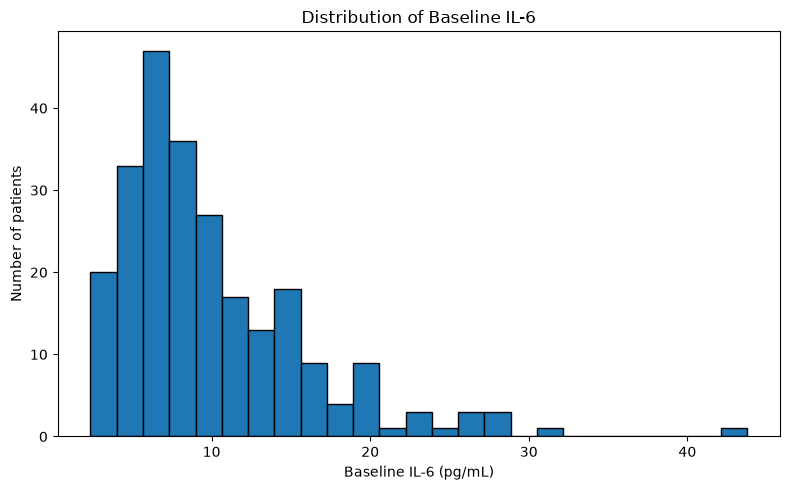

In [64]:
# Plot the raw baseline IL-6 distribution

plt.figure(figsize=(8, 5))
plt.hist(
    protein_analysis["il6_pg_ml"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.xlabel("Baseline IL-6 (pg/mL)")
plt.ylabel("Number of patients")
plt.title("Distribution of Baseline IL-6")
plt.tight_layout()
plt.show()

## 10. Log transformation of IL-6

### Objective

Reduce the influence of the long right tail and evaluate whether a logarithmic scale
provides a more interpretable representation of IL-6 variation.

Log transformation does not remove biological observations. It changes the scale on
which differences are represented.

In [65]:
# Create a natural-log-transformed IL-6 variable

protein_analysis["log_il6"] = np.log(
    protein_analysis["il6_pg_ml"]
)

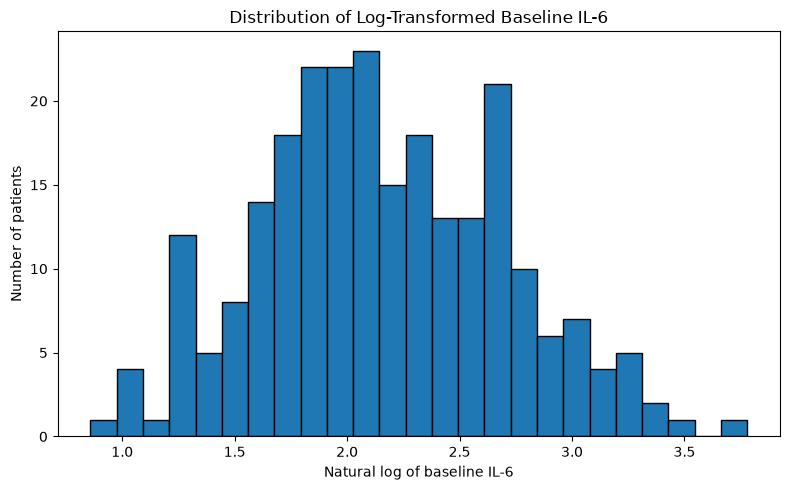

In [66]:
# Plot the log-transformed baseline IL-6 distribution

plt.figure(figsize=(8, 5))
plt.hist(
    protein_analysis["log_il6"].dropna(),
    bins=25,
    edgecolor="black"
)

plt.xlabel("Natural log of baseline IL-6")
plt.ylabel("Number of patients")
plt.title("Distribution of Log-Transformed Baseline IL-6")
plt.tight_layout()
plt.show()

In [67]:
# Compare raw and log-transformed IL-6 skewness

print("Raw IL-6 skewness:", protein_analysis["il6_pg_ml"].skew())
print("Log IL-6 skewness:", protein_analysis["log_il6"].skew())

Raw IL-6 skewness: 1.7690941466273506
Log IL-6 skewness: 0.2066851244495779


## 11. Baseline IL-6 by treatment arm

### Objective

Describe and visualize baseline IL-6 distributions separately for the SOC and
TRIDENT + SOC groups.

Because these are baseline measurements, a large difference could indicate chance
imbalance, population differences, sample-selection effects, or data-quality issues.
No formal statistical test is performed at this stage.

In [68]:
# Calculate descriptive IL-6 statistics by treatment arm

il6_summary = (
    protein_analysis
    .groupby("treatment_arm")["il6_pg_ml"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

il6_summary

,count,mean,median,std,min,max
treatment_arm,,,,,,
SOC,122,9.087,7.460,5.270,2.360,28.340
TRIDENT + SOC,124,11.008,9.250,6.506,2.870,43.770


In [69]:
# Prepare IL-6 values from each treatment arm for a boxplot

soc_il6 = protein_analysis.loc[
    protein_analysis["treatment_arm"] == "SOC",
    "il6_pg_ml"
].dropna()

trident_il6 = protein_analysis.loc[
    protein_analysis["treatment_arm"] == "TRIDENT + SOC",
    "il6_pg_ml"
].dropna()

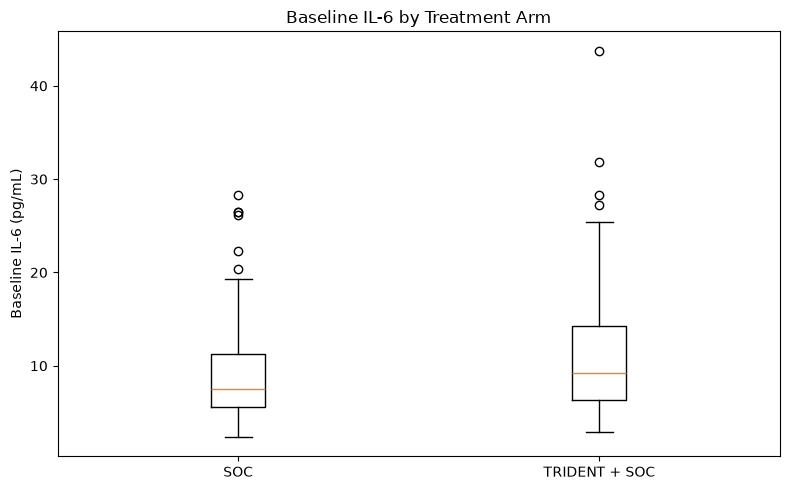

In [70]:
# Plot baseline IL-6 boxplots by treatment arm

plt.figure(figsize=(8, 5))
plt.boxplot(
    [soc_il6, trident_il6],
    tick_labels=["SOC", "TRIDENT + SOC"]
)

plt.ylabel("Baseline IL-6 (pg/mL)")
plt.title("Baseline IL-6 by Treatment Arm")
plt.tight_layout()
plt.show()

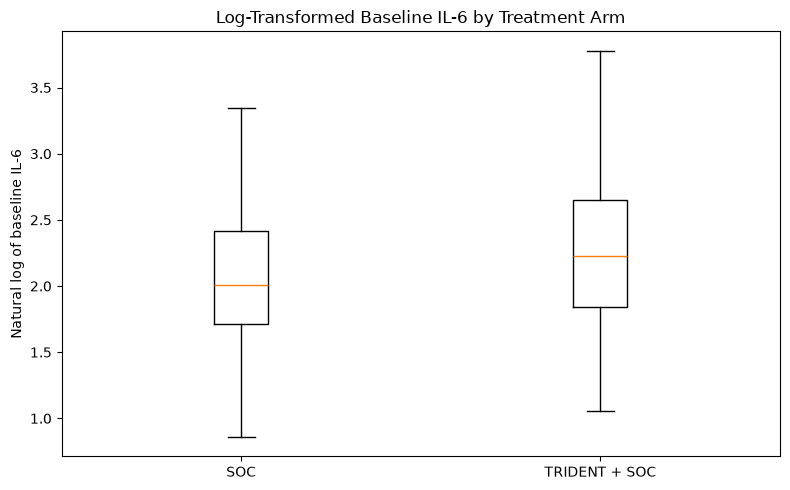

In [71]:
# Plot log-transformed baseline IL-6 by treatment arm

soc_log_il6 = protein_analysis.loc[
    protein_analysis["treatment_arm"] == "SOC",
    "log_il6"
].dropna()

trident_log_il6 = protein_analysis.loc[
    protein_analysis["treatment_arm"] == "TRIDENT + SOC",
    "log_il6"
].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(
    [soc_log_il6, trident_log_il6],
    tick_labels=["SOC", "TRIDENT + SOC"]
)

plt.ylabel("Natural log of baseline IL-6")
plt.title("Log-Transformed Baseline IL-6 by Treatment Arm")
plt.tight_layout()
plt.show()

### Baseline IL-6 interpretation

Baseline IL-6 is right-skewed in both treatment groups, with the mean exceeding the
median. The TRIDENT + SOC group appears to have a somewhat higher IL-6 distribution
than the SOC group.

This observation is descriptive and does not establish a statistically significant
baseline difference. Formal testing should consider the skewed distribution, possible
outliers, and the scientific purpose of comparing randomized baseline groups.

## 12. IL-6 and CRP biological relationship

### Objective

Visually assess whether baseline IL-6 and CRP move together in a manner consistent
with the biological role of IL-6 in stimulating the hepatic acute-phase response.

The scatter plot will be interpreted before Pearson or Spearman correlations are
calculated.

In [72]:
# Create a complete IL-6 and CRP analysis subset

il6_crp_data = protein_analysis[
    ["patient_id", "il6_pg_ml", "crp_mg_l", "treatment_arm"]
].dropna(
    subset=["il6_pg_ml", "crp_mg_l"]
)

print("Patients included in IL-6 and CRP analysis:", len(il6_crp_data))

Patients included in IL-6 and CRP analysis: 245


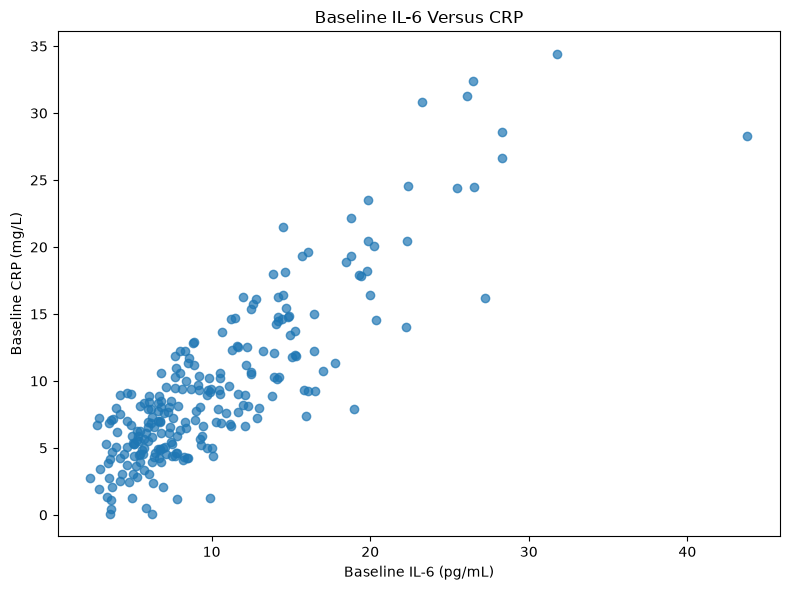

In [73]:
# Plot baseline IL-6 against baseline CRP

plt.figure(figsize=(8, 6))
plt.scatter(
    il6_crp_data["il6_pg_ml"],
    il6_crp_data["crp_mg_l"],
    alpha=0.7
)

plt.xlabel("Baseline IL-6 (pg/mL)")
plt.ylabel("Baseline CRP (mg/L)")
plt.title("Baseline IL-6 Versus CRP")
plt.tight_layout()
plt.show()

## 13. Investigation of the high IL-6 observation

### Objective

Determine whether the visually extreme IL-6 measurement corresponds to an impossible
value, a likely technical problem, or a biologically plausible patient.

An outlier should not be removed solely because it is visually unusual.

In [74]:
# Display patients with the highest baseline IL-6 measurements

protein_analysis[
    [
        "patient_id",
        "treatment_arm",
        "il6_pg_ml",
        "crp_mg_l",
        "tnf_alpha_pg_ml",
        "disease_stage",
        "best_overall_response",
    ]
].sort_values(
    "il6_pg_ml",
    ascending=False
).head(10)

,patient_id,treatment_arm,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,disease_stage,best_overall_response
146,TRI-147,TRIDENT + SOC,43.770,28.300,8.750,IV,SD
82,TRI-083,TRIDENT + SOC,31.810,34.390,4.090,III,PD
97,TRI-098,SOC,28.340,26.650,5.260,III,SD
162,TRI-163,TRIDENT + SOC,28.340,28.570,4.290,IV,PR
52,TRI-053,TRIDENT + SOC,27.230,16.220,3.180,IV,SD
143,TRI-144,SOC,26.530,24.510,4.120,III,PD
55,TRI-056,SOC,26.480,32.400,6.940,IV,PD
149,TRI-150,SOC,26.120,31.290,6.680,III,PR
180,TRI-181,TRIDENT + SOC,25.460,24.390,4.960,IV,PD
128,TRI-129,TRIDENT + SOC,23.260,30.830,3.010,IV,PR


In [75]:
# Verify that CRP values are positive before logarithmic transformation

print("Zero CRP values:", (il6_crp_data["crp_mg_l"] == 0).sum())
print("Negative CRP values:", (il6_crp_data["crp_mg_l"] < 0).sum())

Zero CRP values: 0
Negative CRP values: 0


In [76]:
# Add log-transformed IL-6 and CRP values for visual comparison

il6_crp_data = il6_crp_data.copy()

il6_crp_data["log_il6"] = np.log(il6_crp_data["il6_pg_ml"])
il6_crp_data["log_crp"] = np.log(il6_crp_data["crp_mg_l"])

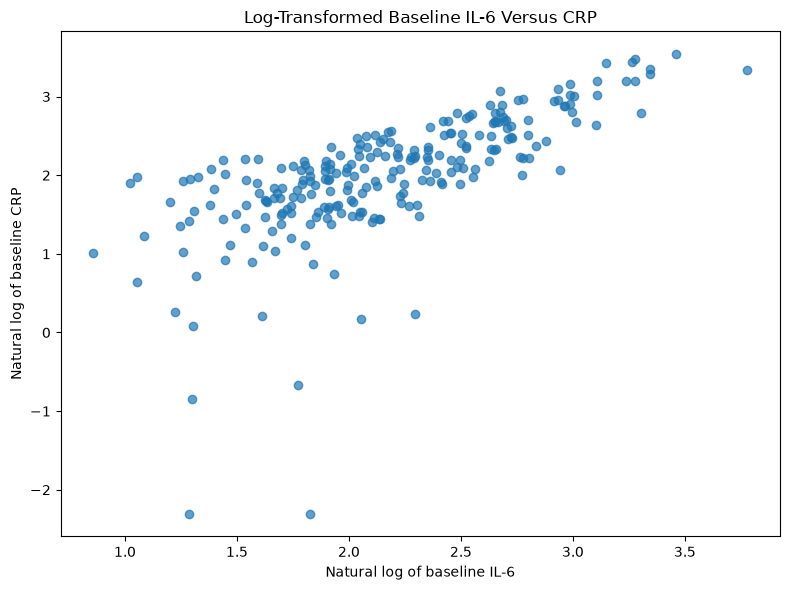

In [77]:
# Plot log-transformed IL-6 against log-transformed CRP

plt.figure(figsize=(8, 6))
plt.scatter(
    il6_crp_data["log_il6"],
    il6_crp_data["log_crp"],
    alpha=0.7
)

plt.xlabel("Natural log of baseline IL-6")
plt.ylabel("Natural log of baseline CRP")
plt.title("Log-Transformed Baseline IL-6 Versus CRP")
plt.tight_layout()
plt.show()

## 14. Biomarker correlation preparation

### Objective

Prepare the seven baseline biomarkers for pairwise correlation analysis.

Pearson correlation will evaluate linear relationships using the numerical values.
Spearman correlation will evaluate monotonic relationships using ranks and will be
less sensitive to extreme values and skewed distributions.

Missingness will be handled pairwise by pandas when calculating the correlation
matrix, allowing each biomarker pair to use all patients with both measurements.

In [78]:
# Select the seven baseline biomarkers for correlation analysis

corr_data = protein_analysis[biomarker_columns].copy()

corr_data.shape

(247, 7)

In [79]:
# Summarize the number of available measurements for each biomarker

corr_data.count().to_frame("nonmissing_measurements")

,nonmissing_measurements
il6_pg_ml,246
crp_mg_l,246
tnf_alpha_pg_ml,247
ifn_gamma_pg_ml,247
vegf_pg_ml,247
pdl1_tps_percent,247
ctdna_fraction_percent,247


In [80]:
# Calculate the number of patients available for each biomarker pair

pairwise_sample_sizes = corr_data.notna().astype(int).T.dot(
    corr_data.notna().astype(int)
)

pairwise_sample_sizes

,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
il6_pg_ml,246,245,246,246,246,246,246
crp_mg_l,245,246,246,246,246,246,246
tnf_alpha_pg_ml,246,246,247,247,247,247,247
ifn_gamma_pg_ml,246,246,247,247,247,247,247
vegf_pg_ml,246,246,247,247,247,247,247
pdl1_tps_percent,246,246,247,247,247,247,247
ctdna_fraction_percent,246,246,247,247,247,247,247


## 15. Pearson and Spearman correlations

### Objective

Compare linear and monotonic associations among inflammatory, immune activation,
angiogenic, checkpoint, and tumor-burden biomarkers.

The coefficients will be interpreted using the scatter plots, sample sizes, data
quality, and biological plausibility. Correlation does not establish causation.

In [81]:
# Calculate the Pearson correlation matrix

pearson_corr = corr_data.corr(method="pearson")

pearson_corr.round(2)

,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
il6_pg_ml,1.000,0.860,-0.090,0.020,-0.020,-0.030,0.030
crp_mg_l,0.860,1.000,-0.130,-0.040,-0.030,-0.030,0.040
tnf_alpha_pg_ml,-0.090,-0.130,1.000,-0.060,-0.030,-0.020,0.030
ifn_gamma_pg_ml,0.020,-0.040,-0.060,1.000,-0.050,-0.000,0.080
vegf_pg_ml,-0.020,-0.030,-0.030,-0.050,1.000,0.110,-0.050
pdl1_tps_percent,-0.030,-0.030,-0.020,-0.000,0.110,1.000,-0.090
ctdna_fraction_percent,0.030,0.040,0.030,0.080,-0.050,-0.090,1.000


In [82]:
# Calculate the Spearman correlation matrix

spearman_corr = corr_data.corr(method="spearman")

spearman_corr.round(2)

,il6_pg_ml,crp_mg_l,tnf_alpha_pg_ml,ifn_gamma_pg_ml,vegf_pg_ml,pdl1_tps_percent,ctdna_fraction_percent
il6_pg_ml,1.000,0.780,-0.140,0.050,-0.030,-0.000,0.030
crp_mg_l,0.780,1.000,-0.170,0.000,-0.050,-0.040,0.050
tnf_alpha_pg_ml,-0.140,-0.170,1.000,-0.080,0.010,0.040,-0.050
ifn_gamma_pg_ml,0.050,0.000,-0.080,1.000,-0.030,-0.050,-0.000
vegf_pg_ml,-0.030,-0.050,0.010,-0.030,1.000,0.060,-0.010
pdl1_tps_percent,-0.000,-0.040,0.040,-0.050,0.060,1.000,-0.110
ctdna_fraction_percent,0.030,0.050,-0.050,-0.000,-0.010,-0.110,1.000


In [83]:
# Compare Pearson and Spearman correlations for IL-6 and CRP

print(
    "Pearson IL-6–CRP:",
    round(pearson_corr.loc["il6_pg_ml", "crp_mg_l"], 3)
)

print(
    "Spearman IL-6–CRP:",
    round(spearman_corr.loc["il6_pg_ml", "crp_mg_l"], 3)
)

Pearson IL-6–CRP: 0.857
Spearman IL-6–CRP: 0.78


### Key Findings

- IL-6 and CRP showed the strongest positive correlation, consistent with activation of the acute inflammatory response.
- IFN-γ and PD-L1 demonstrated a moderate positive association consistent with adaptive immune resistance.
- VEGF showed relatively independent behavior, suggesting angiogenic signaling may represent a distinct biological process.
- These analyses are exploratory and require statistical inference and independent validation.

## 16. Correlation heatmaps

### Objective

Visualize correlation patterns across the biomarker panel and identify possible
biological clusters, including systemic inflammation, adaptive immune activation,
angiogenesis, and tumor burden.

In [84]:
# Define readable biomarker labels for figures

biomarker_labels = [
    "IL-6",
    "CRP",
    "TNF-α",
    "IFN-γ",
    "VEGF",
    "PD-L1",
    "ctDNA",
]

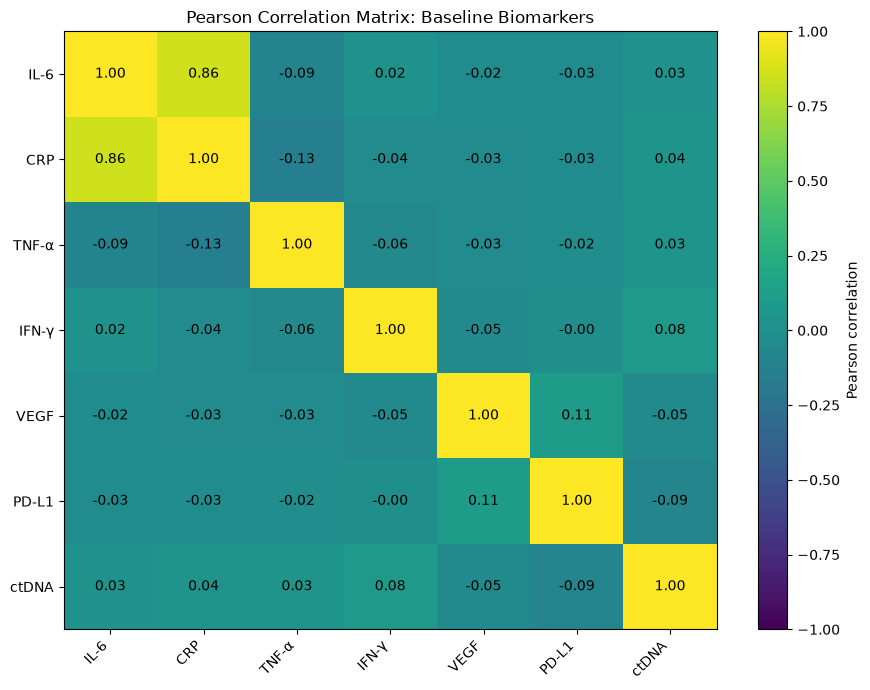

In [85]:
# Plot the Pearson correlation heatmap

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    pearson_corr,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(biomarker_labels)))
ax.set_yticks(range(len(biomarker_labels)))
ax.set_xticklabels(biomarker_labels, rotation=45, ha="right")
ax.set_yticklabels(biomarker_labels)

for row in range(len(biomarker_labels)):
    for column in range(len(biomarker_labels)):
        ax.text(
            column,
            row,
            f"{pearson_corr.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Pearson Correlation Matrix: Baseline Biomarkers")
plt.tight_layout()
plt.show()

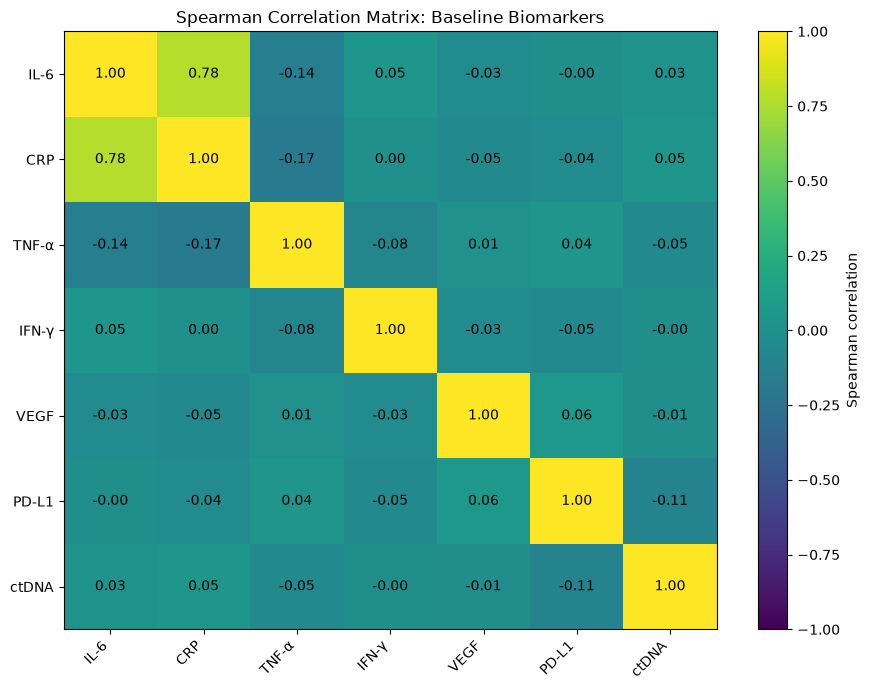

In [86]:
# Plot the Spearman correlation heatmap

fig, ax = plt.subplots(figsize=(9, 7))

image = ax.imshow(
    spearman_corr,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(range(len(biomarker_labels)))
ax.set_yticks(range(len(biomarker_labels)))
ax.set_xticklabels(biomarker_labels, rotation=45, ha="right")
ax.set_yticklabels(biomarker_labels)

for row in range(len(biomarker_labels)):
    for column in range(len(biomarker_labels)):
        ax.text(
            column,
            row,
            f"{spearman_corr.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Spearman Correlation Matrix: Baseline Biomarkers")
plt.tight_layout()
plt.show()

## 17. Save reproducible analysis outputs

### Objective

Save cleaned datasets, QC review tables, and correlation matrices so that downstream
analyses do not depend entirely on the current notebook session.

The raw source files remain unchanged.

In [87]:
# Save the cleaned clinical dataset

clinical_clean.to_csv(
    PROCESSED_DATA_DIR / "clinical_clean.csv",
    index=False
)

In [88]:
# Save the cleaned baseline protein dataset

protein_clean.to_csv(
    PROCESSED_DATA_DIR / "protein_baseline_clean.csv",
    index=False
)

In [89]:
# Save the merged protein analysis dataset

protein_analysis.to_csv(
    PROCESSED_DATA_DIR / "protein_analysis.csv",
    index=False
)

In [90]:
# Save the clinical QC review table

clinical_qc_review.to_csv(
    PROCESSED_DATA_DIR / "clinical_qc_review.csv",
    index=False
)

In [91]:
# Save Pearson and Spearman correlation matrices

pearson_corr.to_csv(
    PROCESSED_DATA_DIR / "pearson_biomarker_correlations.csv"
)

spearman_corr.to_csv(
    PROCESSED_DATA_DIR / "spearman_biomarker_correlations.csv"
)

pairwise_sample_sizes.to_csv(
    PROCESSED_DATA_DIR / "biomarker_pairwise_sample_sizes.csv"
)

In [92]:
# Confirm that the processed files were created

sorted(file.name for file in PROCESSED_DATA_DIR.iterdir())

['biomarker_pairwise_sample_sizes.csv',
 'clinical_clean.csv',
 'clinical_qc_review.csv',
 'pearson_biomarker_correlations.csv',
 'protein_analysis.csv',
 'protein_baseline_clean.csv',
 'spearman_biomarker_correlations.csv']

In [93]:
# Confirm that important analysis conditions are satisfied

assert clinical_clean["patient_id"].is_unique
assert ~protein_clean.duplicated(
    subset=["patient_id", "sample_timepoint"]
).any()

assert protein_analysis["patient_id"].is_unique

assert set(protein_analysis["treatment_arm"].dropna().unique()).issubset(
    {"SOC", "TRIDENT + SOC"}
)

print("All final validation checks passed.")

All final validation checks passed.


## Summary of findings

### Clinical data quality

- The original clinical dataset contained one exact duplicate record for TRI-075.
- The duplicate was removed while retaining one valid patient record.
- TRI-017 had an implausible age of 152 years.
- TRI-089 had an invalid ECOG performance status of 7.
- TRI-102 had a missing best overall response.
- TRI-138 had a negative progression-free survival time of -14 days.
- These anomalies were flagged for source-data review rather than automatically corrected.

### Protein biomarker quality

- The baseline protein dataset contained an exact duplicate record for TRI-032.
- The duplicate was removed while retaining one valid baseline sample.
- Protein biomarker missingness was characterized separately from true zero measurements.
- Treatment-arm labels were standardized.
- Biomarker ranges and extreme values were inspected before analysis.
- Fewer patients had protein measurements than clinical records, consistent with incomplete
  sample availability; this may introduce selection bias if sample availability is nonrandom.

### Baseline IL-6

- Baseline IL-6 was right-skewed.
- The mean exceeded the median in both treatment groups.
- Log transformation reduced the influence of the right tail.
- The TRIDENT + SOC group had a somewhat higher baseline IL-6 distribution than SOC,
  although no formal group-comparison test was performed at this stage.

### IL-6 and CRP

- The scatter plot suggested a generally positive and approximately linear relationship.
- The finding is biologically plausible because IL-6 contributes to hepatic CRP production.
- The relationship was imperfect, as expected, because CRP may also be influenced by
  infection, autoimmune disease, medications, liver function, sampling time, and tumor burden.
- Pearson and Spearman correlations were prepared to compare linear and monotonic association.

### Translational interpretation

Correlation patterns should be interpreted as possible shared biological programs rather
than proof of direct causal relationships. Unexpected correlations require confirmation of
data quality, examination of scatter plots, sensitivity analyses, mechanistic assessment,
and validation in an independent dataset.

# 18. Statistical Inference for Biomarker Correlations

## Objective

Evaluate whether the observed pairwise biomarker correlations are likely to represent true biological associations rather than random sampling variation.

Specifically, this section will:

- Quantify the statistical evidence supporting each observed correlation.
- Distinguish biological effect size from statistical significance.
- Estimate the uncertainty around each correlation using confidence intervals.
- Account for multiple hypothesis testing using the False Discovery Rate (Benjamini–Hochberg correction).
- Identify robust biomarker relationships for future translational analyses.

## Statistical Hypothesis

For each biomarker pair, the null hypothesis is:

> **H₀:** The true population correlation between the two biomarkers is zero.

The alternative hypothesis is:

> **H₁:** The true population correlation is not zero.

## Biological Context

The primary biological relationships of interest include:

- **IL-6 → liver → CRP:** Acute inflammatory response.
- **IL-6, CRP, and TNF-α:** Coordinated inflammatory signature.
- **IFN-γ → PD-L1:** Adaptive immune resistance.
- **VEGF:** Angiogenesis.
- **ctDNA:** Tumor burden.

## Notes

Because multiple biomarker pairs are evaluated simultaneously, adjusted p-values will be reported to reduce the likelihood of false-positive findings.

These analyses are **exploratory** and are intended to generate biological hypotheses that require validation in independent datasets.

## 18.1 Pairwise Correlation Tests

### Objective

Convert the pairwise biomarker correlations into a structured results table that includes:

- Spearman correlation coefficient (effect size)
- Number of paired observations
- Raw p-value

This table will form the basis for confidence interval estimation and multiple-testing correction.

In [94]:
# Import statistical functions for correlation testing

from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

In [95]:
# Calculate Spearman correlations using pairwise complete observations

correlation_results = []

for biomarker_1, biomarker_2 in combinations(corr_data.columns, 2):
    paired_data = corr_data[[biomarker_1, biomarker_2]].dropna()

    spearman_r, raw_p_value = spearmanr(
        paired_data[biomarker_1],
        paired_data[biomarker_2]
    )

    correlation_results.append(
        {
            "biomarker_1": biomarker_1,
            "biomarker_2": biomarker_2,
            "sample_size": len(paired_data),
            "spearman_r": spearman_r,
            "raw_p_value": raw_p_value
        }
    )

correlation_inference = pd.DataFrame(correlation_results)

correlation_inference.head()

,biomarker_1,biomarker_2,sample_size,spearman_r,raw_p_value
0,il6_pg_ml,crp_mg_l,245,0.780,0.000
1,il6_pg_ml,tnf_alpha_pg_ml,246,-0.135,0.034
2,il6_pg_ml,ifn_gamma_pg_ml,246,0.049,0.444
3,il6_pg_ml,vegf_pg_ml,246,-0.034,0.592
4,il6_pg_ml,pdl1_tps_percent,246,-0.001,0.987


### 18.2 Confidence Intervals for Spearman Correlations

Bootstrap resampling was used to estimate 95% confidence intervals for each Spearman correlation.

For each biomarker pair, patients with complete measurements for both biomarkers were repeatedly resampled with replacement. The Spearman correlation was recalculated for each bootstrap sample.

The resulting distribution of correlation coefficients was used to estimate the 95% confidence interval.

Confidence intervals complement p-values by showing the **precision and plausible range of the estimated effect size**.

In [96]:
# Estimate a 95% confidence interval for Spearman correlation using bootstrap resampling

def bootstrap_spearman_ci(x, y, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)

    x = np.asarray(x)
    y = np.asarray(y)

    bootstrap_correlations = []

    for _ in range(n_bootstrap):
        sample_indices = rng.choice(
            len(x),
            size=len(x),
            replace=True
        )

        bootstrap_r, _ = spearmanr(
            x[sample_indices],
            y[sample_indices]
        )

        bootstrap_correlations.append(bootstrap_r)

    ci_lower = np.percentile(bootstrap_correlations, 2.5)
    ci_upper = np.percentile(bootstrap_correlations, 97.5)

    return ci_lower, ci_upper

In [97]:
# Select patients with both IL-6 and CRP measurements available

il6_crp_data = corr_data[
    ["il6_pg_ml", "crp_mg_l"]
].dropna()

print("Paired sample size:", len(il6_crp_data))

Paired sample size: 245


In [98]:
# Estimate the 95% bootstrap confidence interval for the IL-6–CRP Spearman correlation

il6_crp_ci_lower, il6_crp_ci_upper = bootstrap_spearman_ci(
    il6_crp_data["il6_pg_ml"],
    il6_crp_data["crp_mg_l"]
)

print("Spearman r:", round(
    spearmanr(
        il6_crp_data["il6_pg_ml"],
        il6_crp_data["crp_mg_l"]
    ).statistic,
    3
))

print(
    "95% CI:",
    round(il6_crp_ci_lower, 3),
    "to",
    round(il6_crp_ci_upper, 3)
)

Spearman r: 0.78
95% CI: 0.722 to 0.828


In [99]:
# Estimate bootstrap confidence intervals for all unique biomarker pairs

ci_lower_values = []
ci_upper_values = []

for biomarker_1, biomarker_2 in zip(
    correlation_inference["biomarker_1"],
    correlation_inference["biomarker_2"]
):
    paired_data = corr_data[
        [biomarker_1, biomarker_2]
    ].dropna()

    ci_lower, ci_upper = bootstrap_spearman_ci(
        paired_data[biomarker_1],
        paired_data[biomarker_2]
    )

    ci_lower_values.append(ci_lower)
    ci_upper_values.append(ci_upper)

correlation_inference["ci_lower"] = ci_lower_values
correlation_inference["ci_upper"] = ci_upper_values

correlation_inference.head()

,biomarker_1,biomarker_2,sample_size,spearman_r,raw_p_value,ci_lower,ci_upper
0,il6_pg_ml,crp_mg_l,245,0.780,0.000,0.722,0.828
1,il6_pg_ml,tnf_alpha_pg_ml,246,-0.135,0.034,-0.261,-0.017
2,il6_pg_ml,ifn_gamma_pg_ml,246,0.049,0.444,-0.072,0.177
3,il6_pg_ml,vegf_pg_ml,246,-0.034,0.592,-0.160,0.092
4,il6_pg_ml,pdl1_tps_percent,246,-0.001,0.987,-0.116,0.124


### 18.3 Multiple Testing and False Discovery Rate

Testing multiple biomarker pairs increases the probability of identifying statistically significant associations by chance.

Because 21 unique biomarker pairs are evaluated in this analysis, raw p-values are adjusted using the **Benjamini–Hochberg (BH) procedure** to control the **False Discovery Rate (FDR)**.

FDR control is appropriate for this exploratory biomarker analysis because it limits the expected proportion of false discoveries among findings declared significant while retaining greater power to detect potentially meaningful biological signals than more conservative approaches such as Bonferroni correction.

Both raw and FDR-adjusted p-values are retained to distinguish nominal statistical significance from findings that remain significant after multiple-testing correction.

In [100]:
# Apply Benjamini–Hochberg correction to control the False Discovery Rate

from statsmodels.stats.multitest import multipletests

reject_null, fdr_p_values, _, _ = multipletests(
    correlation_inference["raw_p_value"],
    alpha=0.05,
    method="fdr_bh"
)

correlation_inference["fdr_p_value"] = fdr_p_values
correlation_inference["fdr_significant"] = reject_null

correlation_inference.head()

,biomarker_1,biomarker_2,sample_size,spearman_r,raw_p_value,ci_lower,ci_upper,fdr_p_value,fdr_significant
0,il6_pg_ml,crp_mg_l,245,0.780,0.000,0.722,0.828,0.000,True
1,il6_pg_ml,tnf_alpha_pg_ml,246,-0.135,0.034,-0.261,-0.017,0.237,False
2,il6_pg_ml,ifn_gamma_pg_ml,246,0.049,0.444,-0.072,0.177,0.863,False
3,il6_pg_ml,vegf_pg_ml,246,-0.034,0.592,-0.160,0.092,0.863,False
4,il6_pg_ml,pdl1_tps_percent,246,-0.001,0.987,-0.116,0.124,0.990,False


In [101]:
# Rank biomarker associations by strength of Spearman correlation

correlation_ranked = correlation_inference.copy()

correlation_ranked["abs_spearman_r"] = (
    correlation_ranked["spearman_r"].abs()
)

correlation_ranked = correlation_ranked.sort_values(
    "abs_spearman_r",
    ascending=False
)

correlation_ranked[
    [
        "biomarker_1",
        "biomarker_2",
        "sample_size",
        "spearman_r",
        "ci_lower",
        "ci_upper",
        "raw_p_value",
        "fdr_p_value",
        "fdr_significant"
    ]
]

,biomarker_1,biomarker_2,sample_size,spearman_r,ci_lower,ci_upper,raw_p_value,fdr_p_value,fdr_significant
0,il6_pg_ml,crp_mg_l,245,0.780,0.722,0.828,0.000,0.000,True
6,crp_mg_l,tnf_alpha_pg_ml,246,-0.167,-0.287,-0.048,0.009,0.093,False
1,il6_pg_ml,tnf_alpha_pg_ml,246,-0.135,-0.261,-0.017,0.034,0.237,False
20,pdl1_tps_percent,ctdna_fraction_percent,247,-0.106,-0.222,0.015,0.097,0.510,False
11,tnf_alpha_pg_ml,ifn_gamma_pg_ml,247,-0.083,-0.207,0.043,0.195,0.819,False
18,vegf_pg_ml,pdl1_tps_percent,247,0.063,-0.063,0.186,0.321,0.863,False
14,tnf_alpha_pg_ml,ctdna_fraction_percent,247,-0.051,-0.185,0.073,0.423,0.863,False
8,crp_mg_l,vegf_pg_ml,246,-0.050,-0.175,0.085,0.435,0.863,False
2,il6_pg_ml,ifn_gamma_pg_ml,246,0.049,-0.072,0.177,0.444,0.863,False
16,ifn_gamma_pg_ml,pdl1_tps_percent,247,-0.048,-0.175,0.076,0.453,0.863,False


### Interpretation

Among the 21 pairwise biomarker comparisons, the strongest association was observed between IL-6 and CRP (Spearman r = 0.780, 95% CI: 0.722–0.828), which remained statistically significant after FDR correction (FDR p < 0.001). This strong positive association is consistent with the known biological relationship between IL-6 signaling and hepatic CRP production.

Weak negative associations were observed between TNF-α and both CRP and IL-6. Although these associations reached nominal statistical significance, neither remained significant after FDR correction. Therefore, the current analysis does not provide robust statistical support for a coordinated TNF-α association with IL-6 or CRP at baseline.

No clear association was observed between baseline IFN-γ and PD-L1. Although IFN-γ-mediated PD-L1 induction is biologically consistent with adaptive immune resistance, this expected relationship was not detected in the current baseline dataset.

Overall, IL-6–CRP represents the most robust biomarker association identified in this exploratory analysis. Other observed relationships should be interpreted cautiously and require validation in independent datasets.

In [102]:
# Create a presentation-ready table of biomarker correlation results

correlation_summary = correlation_ranked[
    [
        "biomarker_1",
        "biomarker_2",
        "sample_size",
        "spearman_r",
        "ci_lower",
        "ci_upper",
        "raw_p_value",
        "fdr_p_value",
        "fdr_significant"
    ]
].copy()

correlation_summary[
    ["spearman_r", "ci_lower", "ci_upper"]
] = correlation_summary[
    ["spearman_r", "ci_lower", "ci_upper"]
].round(3)

correlation_summary

,biomarker_1,biomarker_2,sample_size,spearman_r,ci_lower,ci_upper,raw_p_value,fdr_p_value,fdr_significant
0,il6_pg_ml,crp_mg_l,245,0.780,0.722,0.828,0.000,0.000,True
6,crp_mg_l,tnf_alpha_pg_ml,246,-0.167,-0.287,-0.048,0.009,0.093,False
1,il6_pg_ml,tnf_alpha_pg_ml,246,-0.135,-0.261,-0.017,0.034,0.237,False
20,pdl1_tps_percent,ctdna_fraction_percent,247,-0.106,-0.222,0.015,0.097,0.510,False
11,tnf_alpha_pg_ml,ifn_gamma_pg_ml,247,-0.083,-0.207,0.043,0.195,0.819,False
18,vegf_pg_ml,pdl1_tps_percent,247,0.063,-0.063,0.186,0.321,0.863,False
14,tnf_alpha_pg_ml,ctdna_fraction_percent,247,-0.051,-0.185,0.073,0.423,0.863,False
8,crp_mg_l,vegf_pg_ml,246,-0.050,-0.175,0.085,0.435,0.863,False
2,il6_pg_ml,ifn_gamma_pg_ml,246,0.049,-0.072,0.177,0.444,0.863,False
16,ifn_gamma_pg_ml,pdl1_tps_percent,247,-0.048,-0.175,0.076,0.453,0.863,False


In [103]:
# Create readable biomarker labels for the presentation table

biomarker_labels = {
    "il6_pg_ml": "IL-6",
    "crp_mg_l": "CRP",
    "tnf_alpha_pg_ml": "TNF-α",
    "ifn_gamma_pg_ml": "IFN-γ",
    "vegf_pg_ml": "VEGF",
    "pdl1_tps_percent": "PD-L1",
    "ctdna_fraction_percent": "ctDNA"
}

correlation_display = correlation_summary.copy()

correlation_display["biomarker_1"] = (
    correlation_display["biomarker_1"].map(biomarker_labels)
)

correlation_display["biomarker_2"] = (
    correlation_display["biomarker_2"].map(biomarker_labels)
)

In [104]:
# Format p-values for clear scientific reporting

def format_p_value(p_value):
    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


correlation_display["raw_p_value"] = (
    correlation_display["raw_p_value"].apply(format_p_value)
)

correlation_display["fdr_p_value"] = (
    correlation_display["fdr_p_value"].apply(format_p_value)
)

correlation_display

,biomarker_1,biomarker_2,sample_size,spearman_r,ci_lower,ci_upper,raw_p_value,fdr_p_value,fdr_significant
0,IL-6,CRP,245,0.780,0.722,0.828,<0.001,<0.001,True
6,CRP,TNF-α,246,-0.167,-0.287,-0.048,0.009,0.093,False
1,IL-6,TNF-α,246,-0.135,-0.261,-0.017,0.034,0.237,False
20,PD-L1,ctDNA,247,-0.106,-0.222,0.015,0.097,0.510,False
11,TNF-α,IFN-γ,247,-0.083,-0.207,0.043,0.195,0.819,False
18,VEGF,PD-L1,247,0.063,-0.063,0.186,0.321,0.863,False
14,TNF-α,ctDNA,247,-0.051,-0.185,0.073,0.423,0.863,False
8,CRP,VEGF,246,-0.050,-0.175,0.085,0.435,0.863,False
2,IL-6,IFN-γ,246,0.049,-0.072,0.177,0.444,0.863,False
16,IFN-γ,PD-L1,247,-0.048,-0.175,0.076,0.453,0.863,False


In [105]:
# Save the numeric correlation results for reproducible downstream analysis

correlation_summary.to_csv(
    RESULTS_DIR / "biomarker_correlation_inference.csv",
    index=False
)

In [106]:
# Save the human-readable correlation table for reporting

correlation_display.to_csv(
    RESULTS_DIR / "biomarker_correlation_inference_formatted.csv",
    index=False
)

In [107]:
# Confirm that both correlation result files were saved successfully

print(
    RESULTS_DIR / "biomarker_correlation_inference.csv"
)

print(
    RESULTS_DIR / "biomarker_correlation_inference_formatted.csv"
)

/Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/biomarker_correlation_inference.csv
/Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/results/biomarker_correlation_inference_formatted.csv


## Key Findings

- Among 21 unique baseline biomarker pairs, **IL-6 and CRP showed the strongest association** (Spearman r = 0.780, 95% CI: 0.722–0.828, FDR-adjusted p < 0.001).

- The strong positive IL-6–CRP association is **consistent with the known biological relationship between IL-6 signaling and hepatic CRP production**.

- CRP–TNF-α (r = -0.167, raw p = 0.009) and IL-6–TNF-α (r = -0.135, raw p = 0.034) showed weak negative associations that reached **nominal statistical significance**, but neither remained significant after FDR correction.

- No clear baseline association was detected between **IFN-γ and PD-L1** (r = -0.048, 95% CI: -0.175–0.076), despite the biological rationale linking IFN-γ signaling to PD-L1 expression and adaptive immune resistance.

- Overall, the analysis supports **IL-6–CRP as the most robust baseline biomarker relationship** in this dataset. Other observed associations were weak and should be interpreted cautiously.

- These findings are exploratory and **require validation in independent datasets** before drawing confirmatory biological or clinical conclusions.